# Gera Dataset

In [ ]:
import subprocess
import random
import time
import json
import os

# CONFIGURAÇÕES DA BATERIA DE TESTES
LISTA_N_BITS = [4, 8, 12, 16, 20, 24, 32, 48, 64]
OPERACOES = ["add", "sub", "mul", "div", "fat"]
QUANTIDADE_TESTES_POR_BIT = 50  # Total de testes por tamanho de palavra

# Determina a quantidade exata de repetições fixas para cada operação
TESTES_POR_OP = QUANTIDADE_TESTES_POR_BIT // len(OPERACOES)

EXECUTAVEL = "benchmarkOperation.exe" if os.name == 'nt' else "./benchmarkOperation"

# ESTRUTURA ALVO: Dicionário de Matrizes (Lista de arrays) mapeado por N_BITS
dados_por_bits = {}

print(f"🚀 Iniciando automação de testes com distribuição igualitária ({TESTES_POR_OP} testes por operação)...")

def gerar_binario_aleatorio(limite_inf, limite_sup, n_bits):
    num = random.randint(limite_inf, limite_sup)
    if num < 0:
        bits = (1 << n_bits) + num
    else:
        bits = num
    return bin(bits)[2:].zfill(n_bits)

for n in LISTA_N_BITS:
    limite_sup = (1 << (n - 1)) - 1
    limite_inf = -(1 << (n - 1))
    
    print(f" -> Gerando matriz balanceada para barramento de {n} bits...")
    
    # Inicializa a lista de arrays para este tamanho de bit específico
    dados_por_bits[str(n)] = []
    
    # CORREÇÃO: Varre sequencialmente cada operação para garantir a igualdade na amostragem
    for op in OPERACOES:
        for _ in range(TESTES_POR_OP):
            
            bin_a = gerar_binario_aleatorio(limite_inf, limite_sup, n)
            bin_b = gerar_binario_aleatorio(limite_inf, limite_sup, n)
            
            # Tratamento de segurança para divisões e fatoriais no escopo dinâmico de N bits
            if op == "div" and bin_b == bin(0)[2:].zfill(n):
                # Mantém o teste de divisão por zero em apenas 20% dos casos deste bloco fixo
                if random.random() > 0.2: 
                    bin_b = gerar_binario_aleatorio(1, limite_sup, n)
                    
            if op == "fat":
                val_limite_fat = min(limite_sup, 12) 
                bin_a = gerar_binario_aleatorio(0, val_limite_fat, n)
                bin_b = bin(0)[2:].zfill(n)

            # Cronômetro de alta precisão (Hardware Benchmark)
            start_time = time.perf_counter_ns()
            
            comando = [EXECUTAVEL, str(n), bin_a, bin_b, op]
            processo = subprocess.run(comando, capture_output=True, text=True)
            
            end_time = time.perf_counter_ns()
            tempo_microssegundos = (end_time - start_time) / 1000.0

            if processo.returncode == 0:
                saida = processo.stdout.strip().split(',')
                
                # Conversão das saídas textuais do C++ para tipos primitivos do Python
                dec_a = int(saida[0])
                dec_b = int(saida[1])
                res_bruto = int(saida[2])
                res_masc_dec = int(saida[3])
                res_masc_bin = bin(res_masc_dec)[2:].zfill(n)
                overflow_flag = 1 if saida[4] == "1" else 0  

                # Estruturação da linha plana (Array)
                linha_teste = [
                    op,                  # [0] String da operação
                    bin_a,               # [1] String binária A
                    bin_b,               # [2] String binária B
                    dec_a,               # [3] Inteiro decimal A
                    dec_b,               # [4] Inteiro decimal B
                    res_bruto,           # [5] Inteiro resultado bruto 32-bits
                    res_masc_dec,        # [6] Inteiro resultado mascarado decimal
                    res_masc_bin,        # [7] String resultado mascarado binário
                    overflow_flag,       # [8] Inteiro de controle de Overflow (0 ou 1)
                    tempo_microssegundos # [9] Float do benchmark de tempo em us
                ]
                
                dados_por_bits[str(n)].append(linha_teste)
            else:
                print(f"  Falha no subprocesso em {n} bits: {processo.stderr}")

# Opcional: Embaralha a matriz final de cada bit caso queira que a ordem de execução
# no histórico pareça aleatória no log, mantendo as quantidades perfeitamente iguais
for n_str in dados_por_bits:
    random.shuffle(dados_por_bits[n_str])

print("\n✅ Concluído! Matrizes balanceadas carregadas na estrutura 'dados_por_bits'.")

Iniciando automação de testes com estrutura em Matrizes (N=5)...
 -> Gerando matriz de testes para barramento de 4 bits...
 -> Gerando matriz de testes para barramento de 8 bits...
 -> Gerando matriz de testes para barramento de 12 bits...
 -> Gerando matriz de testes para barramento de 16 bits...
 -> Gerando matriz de testes para barramento de 20 bits...
 -> Gerando matriz de testes para barramento de 24 bits...


# Roda grafico

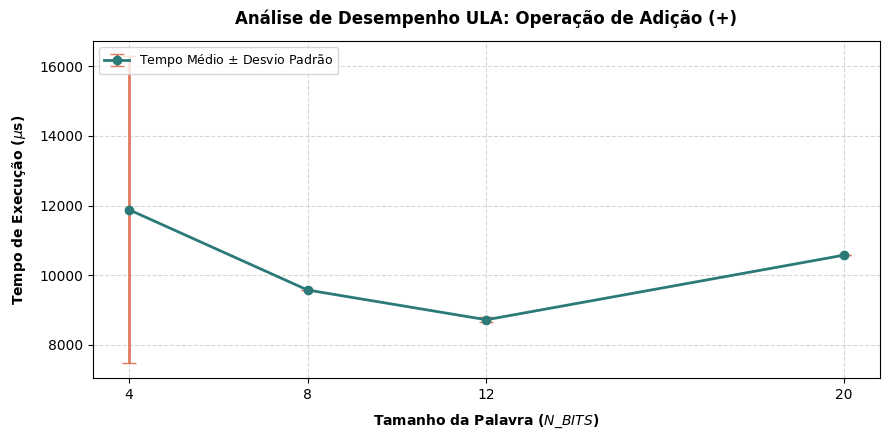

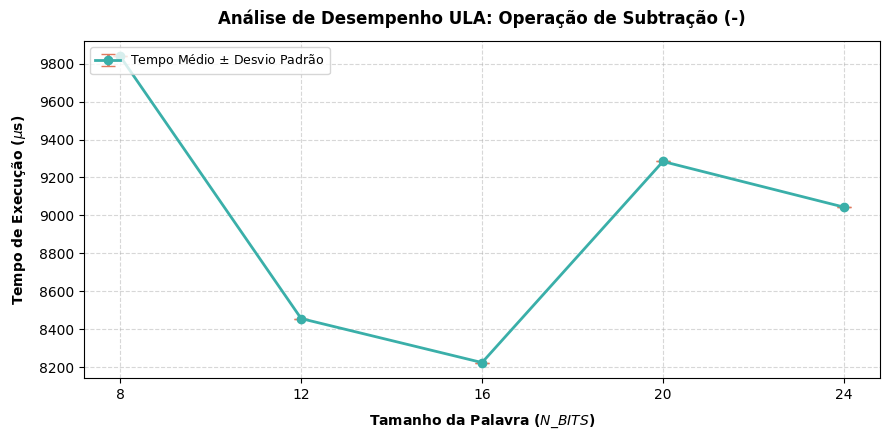

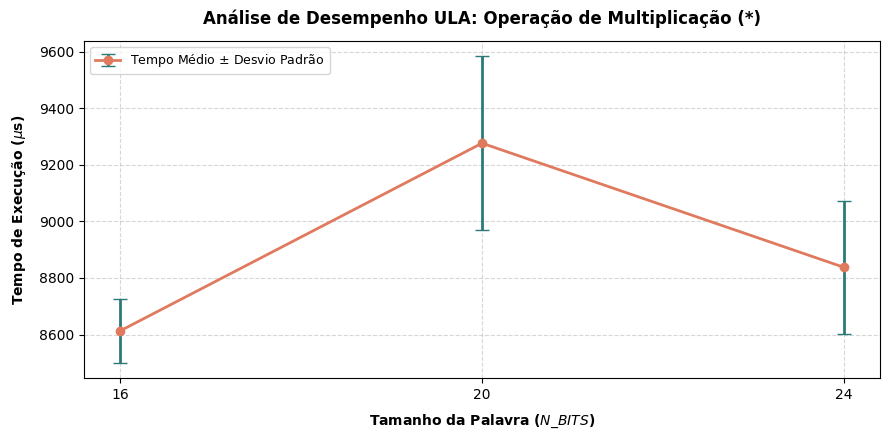

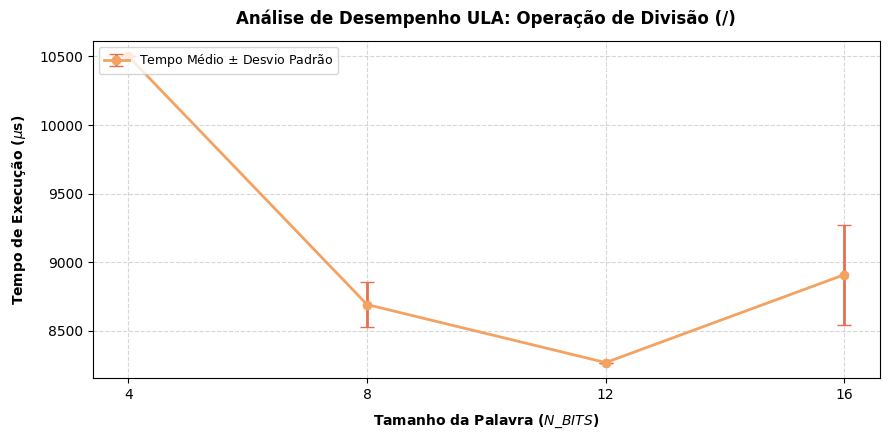

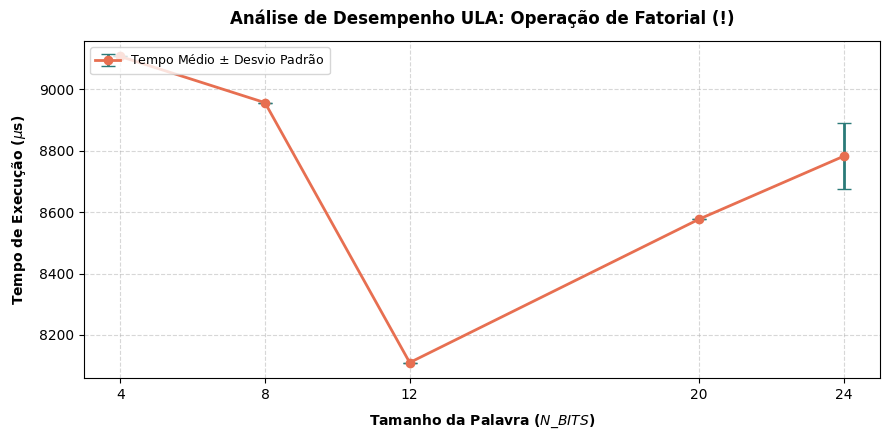

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Garante que os gráficos do matplotlib sejam renderizados inline no seu notebook
%matplotlib inline

# Índices das colunas da sua estrutura de matrizes (lista de arrays)
INDICE_OPERACAO = 0
INDICE_TEMPO = 9

# Definição das operações com seus respectivos nomes e paletas de cores para o relatório
operacoes_map = {
    "add": {"nome": "Adição (+)", "cor": "#2b7a78", "cor_erro": "#e07a5f"},
    "sub": {"nome": "Subtração (-)", "cor": "#3aafa9", "cor_erro": "#e07a5f"},
    "mul": {"nome": "Multiplicação (*)", "cor": "#e07a5f", "cor_erro": "#2b7a78"},
    "div": {"nome": "Divisão (/)", "cor": "#f4a261", "cor_erro": "#e76f51"},
    "fat": {"nome": "Fatorial (!)", "cor": "#e76f51", "cor_erro": "#2b7a78"}
}

# O loop vai iterar e gerar um gráfico completamente isolado por operação
for op, info in operacoes_map.items():
    lista_bits = []
    medias_tempo = []
    desvios_padrao_tempo = []
    
    # Varre a estrutura dinâmica de dados carregada na memória
    for n_bit_str, matriz_testes in dados_por_bits.items():
        if not matriz_testes:
            continue
            
        # FILTRO CRUCIAL: Extrai o tempo (índice 9) apenas se a linha pertencer à operação atual
        tempos_filtrados = [linha[INDICE_TEMPO] for linha in matriz_testes if linha[INDICE_OPERACAO] == op]
        
        # Se este tamanho de bit não possuir amostragem para a operação atual, pula
        if not tempos_filtrados:
            continue
            
        vetor_tempos = np.array(tempos_filtrados)
        
        # Acumula as métricas calculadas pelo NumPy
        lista_bits.append(int(n_bit_str))
        medias_tempo.append(np.mean(vetor_tempos))
        desvios_padrao_tempo.append(np.std(vetor_tempos))
        
    # Se a operação não possuir dados na estrutura, pula a plotagem dela
    if not lista_bits:
        continue
        
    # Ordena os eixos pelo número de bits para evitar linhas cruzadas na renderização
    dados_ordenados = sorted(zip(lista_bits, medias_tempo, desvios_padrao_tempo))
    lista_bits_plot, medias_tempo_plot, desvios_padrao_tempo_plot = zip(*dados_ordenados)
    
    # Cria uma nova janela de figura para cada gráfico de forma sequencial
    plt.figure(figsize=(9, 4.5), dpi=100)
    
    # Plota o gráfico de dispersão com as barras de erro verticais (Desvio Padrão)
    plt.errorbar(
        lista_bits_plot, 
        medias_tempo_plot, 
        yerr=desvios_padrao_tempo_plot, 
        fmt='-o', 
        color=info["cor"], 
        ecolor=info["cor_erro"], 
        elinewidth=2, 
        capsize=5, 
        linewidth=2, 
        label=r'Tempo Médio $\pm$ Desvio Padrão'
    )
    
    # Customização técnica dos eixos (utilizando strings puras em LaTeX para símbolos científicos)
    plt.title(f"Análise de Desempenho ULA: Operação de {info['nome']}", fontsize=12, fontweight='bold', pad=12)
    plt.xlabel(r"Tamanho da Palavra ($N\_BITS$)", fontsize=10, fontweight='bold', labelpad=8)
    plt.ylabel(r"Tempo de Execução ($\mu$s)", fontsize=10, fontweight='bold', labelpad=8)
    
    plt.xticks(lista_bits_plot)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc="upper left", fontsize=9)
    
    # Renderiza e limpa o buffer do Matplotlib para a próxima iteração do loop
    plt.tight_layout()
    plt.show()